### Multimodal RAG
Ref: https://github.com/surendra382/MultiModal-RAG2/blob/main/multimodal_rag_groq.ipynb

Prerequisite: install poppler + Tesseract-OCR and put them on PATH

Using unstrcutured library to seperately extract the text, image and tables from the PDF as internally it used Tessaract and Poppler which we need to add in the Environmental path

As similar to tesseract we have LlamaIndex which is also a parsing platform(But internally it used LLM as it is an API one we send our doc it will return us the data in the form of markup language(HTML)) to extract the multiple format, but it is paid

As the question arises that how does this library keep the row and col as is, without disturbing it - this is because it gets converted into an HTML format

- Using unstructured Library(partition_pdf function) for text, image and tables
- Using Vision models
- Using Pillow for Image processing

In [ ]:
# ! pip install unstructured[all-docs]
# ! pip install unstructured
# ! pip install unstructured-inference
#! pip install tesseract! pip install lxml
# ! pip install "Pillow<12.0.0"
# ! pip install langchain-openai python-dotenv
! pip install langchain_chroma langchain_classic

In [1]:
from unstructured.partition.pdf import partition_pdf

chunks = partition_pdf(
    filename="multimodal_rag_test.pdf",
    infer_table_structure=True,  # Analyze tables into structured rows and columns, extract tables from doc
    strategy="hi_res",  # Required for table inference
    extract_image_block_types=["Image"], # Add 'Table' in the list if you want to extract the table in the form of image, as we have not added in the list as we want to extract the data of the table in the exact format it is present without breaking the row and column for that it will return the table in the HTML format
    extract_image_block_to_payload=True, # If true, while extracting It will convert store the base64(Converting binary image data into a plain text string of ASCII character) format into the metadata to display it into the UI

    # Chunking Strategy
    chunking_strategy="by_title",  # To group the chunks on the basis of title
    max_characters=1000, # Maximum character a single chunk can have
    combine_text_under_n_chars=200, # If the no. of character are lesser than 200 then it will combine some more characters from next chunk
    new_after_n_chars=600, # if the no. of chars are greater than 600 then it will not accept the next chars
)

c:\Users\bahad\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No languages specified, defaulting to English.
Loading weights: 100%|██████████| 367/367 [00:00<00:00, 2692.46it/s]


In [2]:
# chunks
len(chunks)

18

In [3]:
# # We get 3 types of elements from partition_pdf function - CompositeElement, Table, TableChunk
# # Each CompositeElement contains the bunch of related element, this makes it easy to use these elements together in a RAG pipeline


# set(str(type(chunk)) for chunk in chunks)
[chunk for chunk in chunks]

# # len(chunks)

In [4]:
# To visualize the chunks

chunks[1].metadata.orig_elements[4].to_dict()

{'type': 'NarrativeText',
 'element_id': '66a7b670-517b-4059-9ffe-b6964e30399e',
 'text': 'The system recognizes five evidence classes: narrative text, tables, images, diagrams and metadata. Every extracted element receives a document identifier, page number, section identifier, modality label and confidence score. Related evidence is joined with an evidence_group_id.',
 'metadata': {'detection_class_prob': 0.9291603565216064,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(263.41865277777777),
     np.float64(711.0818749999996)),
    (np.float64(263.41865277777777), np.float64(887.5402083333332)),
    (np.float64(2610.1832361111083), np.float64(887.5402083333332)),
    (np.float64(2610.1832361111083), np.float64(711.0818749999996))),
   'system': 'PixelSpace',
   'layout_width': 2894,
   'layout_height': 4093},
  'last_modified': '2026-09-17T10:08:16',
  'filetype': 'PNG',
  'languages': ['eng'],
  'page_number': 2}}

In [5]:
# To Distinguish the compositeElementChunk and tableChunk

from unstructured.documents.elements import CompositeElement, Table, Image as ImageEl

# compositeElemChunk = [chunk for chunk in chunks if isinstance(chunk, CompositeElement)]
# len(compositeElemChunk) # 11

# tableChunk = [chunk for chunk in chunks if isinstance(chunk, Table)]
# len(tableChunk) # 7

### Seperating Text, Tables and Images

### Aggregate Table chunks

In [6]:
# Seperating TableChunk
# Composite (it has text and image inside it) and Table

tables = [chunk for chunk in chunks if isinstance(chunk, Table)]
len(tables)

7

### Extract tables as html in a list

In [8]:
tablehtml = [ el.metadata.text_as_html for el in tables ]
tablehtml

['<table><tr><td>Objective</td><td>Description</td><td>Target</td></tr><tr><td>Recall</td><td>Retrieve evidence needed to answer a question</td><td>2 0.90</td></tr><tr><td>Grounding</td><td>Factual claims supported by evidence</td><td>20.95</td></tr><tr><td>Modality coverage</td><td>Correctly retrieve text/tables/figures</td><td>20.90</td></tr><tr><td>Latency</td><td>Query to first grounded result</td><td>&lt;25s</td></tr><tr><td>Traceability</td><td>Return page and evidence type</td><td>100%</td></tr></table>',
 '<table><tr><td>Component</td><td>Responsibility</td><td>Metadata</td></tr><tr><td>PDF Ingestion</td><td>Preserve page/layout</td><td>doc_id, page_no, block_id</td></tr><tr><td>Content Extraction</td><td>Create modality evidence</td><td>modality, bbox, confidence</td></tr><tr><td>Text Index</td><td>Semantic + lexical retrieval</td><td>chunk_id, section_id</td></tr><tr><td>Table Index</td><td>Rows + summaries</td><td>table_id, row_id, header</td></tr><tr><td>Image Index</td><td

### Storing all composite chunks in texts list and all images into images list (Basically texts chunks also has images in it, but we have made exclusive list images as well)

In [9]:
texts_with_images = [ch for ch in chunks if isinstance(ch, CompositeElement)]

images_b64 = []
images_pages = []

for text in texts_with_images:
    for el in text.metadata.orig_elements or []:
        if isinstance(el, ImageEl):
            
            images_b64.append(el.metadata.image_base64)
            images_pages.append(getattr(el.metadata, "page_number", None))


### In totality we have following chunks

In [10]:
print(f"{len(texts_with_images)} text chunks (including images), {len(images_b64)} images, {len(tables)} tables ")

11 text chunks (including images), 3 images, 7 tables 


### Preview an extracted image
Just to prove the extraction actually pulled real image data out of the PDF.

In [ ]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    display(Image(data=base64.b64decode(base64_code)))

if images_b64:
    display_base64_image(images_b64[2])

 ### Summarize text(With Images) & tables (openai / Groq)

Q) Why summarize at all, if we're going to hand the LLM the original content later? 
- Because we embed the summary for retrieval matching, not the raw chunk — summaries are shorter, more uniform, and tend to match a user's natural-language question better than a raw wall of text or an HTML table. 

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser

prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additional comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}
"""

summarize_prompt = ChatPromptTemplate.from_template(prompt_text)
summarize_model = ChatOllama(model="qwen3:1.7b").with_retry(stop_after_attempt=6, wait_exponential_jitter=True)
# .with_retry() function - Explain us If the model call fails, LangChain will retry it with maximum 6 attempts, wait_exponential_jitter=True means it waits for progressively longer/randomized periods between retries.
summarize_chain = {"element": lambda x : x} | summarize_prompt | summarize_model | StrOutputParser()

# StrOutputParser() Converts the model's response into a normal Python string, here extracts the actual text from that response.So instead of getting a complex object you get a string

text_summaries = summarize_chain.batch([t.text for t in texts_with_images], {"max_concurrency": 1})

# "max_concurrency": 1 - This tells LangChain to process only one model request at a time. Without limiting concurrency, batch processing might send several requests to Ollama simultaneously.

# --> Summarizing tables
table_summaries = summarize_chain.batch(tablehtml, {"max_concurrency": 1})

table_summaries


['The table outlines five objectives with their targets: Recall (20.90%), Grounding (20.95%), Modality coverage (20.90%), Latency (<25s), and Traceability (100%).',
 'The table outlines components and their responsibilities along with metadata fields. For example, PDF Ingestion preserves page/layout with metadata doc_id, page_no, block_id; Content Extraction creates modality evidence with modality, bbox, confidence; Text Index handles semantic/lexical retrieval with chunk_id, section_id; Table Index manages rows and summaries with table_id, row_id, header; Image Index supports visual retrieval with image_id, caption, bbox; and Retriever merges/reranks evidence with scores, evidence_group_id.',
 'The table outlines rules for handling different scenarios in a processing system. Each rule specifies a condition and an action: e.g., if table header confidence is below 0.85, run a fallback parser; if image OCR confidence is below 0.75, keep the image and mark OCR as low confidence. Rules inc

In [12]:
# Creating Image summaries

from langchain_ollama import ChatOllama

prompt_template = """Describe the image in detail. Be specific about flow charts."""
messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatOllama(model="moondream:1.8b") | StrOutputParser()

# {"error":{"code":400,"message":"Multimodal data provided, but model does not support multimodal requests.","type":"invalid_request_error"}} - Got this response after using "qwen3:1.7b" model

image_summaries = chain.batch(images_b64)
image_summaries

['\nThe image presents a flow chart that illustrates the process of ingesting, content extraction, and text indexing. The flow chart is divided into three main sections: ingestion, content extraction, and text indexing. The ingestion section is represented by a box labeled "Ingestion", and the content extraction section is represented by a box labeled "Content Extraction". The text indexing section is represented by a box labeled "Text Indexing". Each box is accompanied by a label that provides information about the corresponding process. The flow chart is set against a white background, making it easy to read and understand.',
 '\nThe image presents a flow chart that illustrates the process of ingesting, content extraction, and indexing. The flow chart is divided into three main sections: ingestion, content extraction, and indexing. The ingestion section is represented by a box labeled "Ingestion", and the content extraction section is represented by a box labeled "Text Index". The in

### Build the multi-vector index

Two stores, one retriever:

- Chroma vectorstore — holds the summary embeddings (what we search against). Embeddings are computed locally with a small sentence-transformers model, so this step needs no API key or quota at all.

- InMemoryStore docstore — holds the original text/table/image content, keyed by a shared doc_id. This is what actually gets handed to the LLM once a summary is matched.
    - InMemoryStore means the parent documents are being held in RAM, the parent documents stored only in that InMemoryStore won't persist across the restart.

**MultiVectorRetriever** glues the two together: search the vectorstore, then look up the matching originals in the docstore.

In [13]:
# print(texts_with_images) # 11
# print(text_summaries) # 11

# print(len(tables)) # 7
# print(len(table_summaries)) # 7

print(len(images_b64)) # 3
print(len(image_summaries)) # 3

3
3


In [14]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(
    model="locusai/all-minilm-l6-v2:latest",
)

### Adding Id's into vector store with summaries and into docstore with original documents

And getting retriver ready for RAG Pipeline

In [ ]:
import uuid
from langchain_core.documents import Document
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore

vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=embeddings)
store = InMemoryStore()
id_key = "doc_id"
retriever = MultiVectorRetriever(vectorstore=vectorstore, docstore=store, id_key=id_key)
# The vectorstore contains the summaries.
# The docstore contains the original documents.

# When the user asks, the retriever searches the vector store using the question and then retriver returns the original documents, below is the complete flow of th retriver
            # Question
            #    ↓
            # Embedding
            #    ↓
            # Chroma
            #    ↓
            # Most similar summaries
            #    ↓
            # IDs
            #    ↓
            # InMemoryStore
            #    ↓
            # Original documents

# Adding id's to vector store and documents
def add(originals, summaries):
    if not originals:
        return
    ids = [str(uuid.uuid4()) for _ in originals]
    summary_docs = [Document(page_content=s, metadata={id_key: ids[i]}) for i, s in enumerate(summaries)]
    retriever.vectorstore.add_documents(summary_docs)
    retriever.docstore.mset(list(zip(ids, originals)))

add(texts_with_images, text_summaries)
add(tables, table_summaries)
add(images_b64, image_summaries)

print("Retriever ready.")

Retriever ready.


### Build the RAG chain

In [ ]:
# data = retriever.vectorstore.get()

# for i, metadata in enumerate(data["metadatas"]):
#     print("Child:", i)
#     print("Metadata:", metadata)
#     print("Document:", data["documents"][i])
#     print()

# ==================================================================================================================

print("=== VECTOR STORE ===")

data = retriever.vectorstore.get()

print("IDs:")
print(data["ids"])

print("\nDocuments:")
print(data["documents"])

print("\nMetadata:")
print(data["metadatas"])

In [16]:
from base64 import b64decode

from langchain_core.runnables import RunnableLambda, RunnablePassthrough

# Creating seperate list for images and texts from retrivers
def parse_docs(docs):
    """Split retrieved docstore entries into base64 images vs. text/table elements."""
    b64, text = [], []
    for doc in docs:
        if isinstance(doc, str):
            try:
                b64decode(doc, validate=True)
                b64.append(doc)
                continue
            except Exception:
                pass
        text.append(doc)
    return {"images": b64, "texts": text}

def build_prompt(kwargs):
    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = "".join(t.text for t in docs_by_type["texts"])
    if docs_by_type["images"]:
        context_text += (
            f"\n\n[{len(docs_by_type['images'])} image(s) from the document were also retrieved as "
            "relevant, but cannot be visually interpreted here \u2014 no vision-capable model is configured.]"
        )

    prompt_template = f"""
Answer the question based only on the following context, which can include text and tables from the document.
No images are visually available to you, even if the question or context references figures. Do not
invent, describe the visual appearance of, or link to any image (e.g. no markdown image syntax or URLs) \u2014
answer using only the textual context, and say so if the question truly requires seeing an image.
Context: {context_text}
Question: {user_question}
"""
    return ChatPromptTemplate.from_template(prompt_template)

answer_model = ChatOllama(model="qwen3:1.7b").with_retry(stop_after_attempt=6, wait_exponential_jitter=True)

chain = (
    {"context": retriever | RunnableLambda(parse_docs), # Why RunnableLambda(parse_docs)?: The key reason is that parse_docs is a normal Python function, while RunnableLambda(parse_docs) converts that function into a LangChain Runnable that can participate in an LCEL chain.
     "question": RunnablePassthrough()} # RunnablePassthrough: Pass the original input through without changing it. This is necessary because the retriever consumes the question, but you also need the original question later when constructing the prompt.
    | RunnableLambda(build_prompt) # So whatever this dictionary produces is passed to build_prompt() func 
    | answer_model
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=RunnableLambda(build_prompt) | answer_model | StrOutputParser()
)

print("Chain ready.")

Chain ready.


In [17]:
def ask(question):
    response = chain_with_sources.invoke(question)
    print("Question:", question)
    print("\nResponse:", response["response"])
    print("\n--- Sources ---")
    for text in response["context"]["texts"]:
        page = getattr(text.metadata, "page_number", None)
        print(f"[text, page {page}] {text.text[:200]}...")
    for _ in response["context"]["images"]:
        print("[image retrieved, not shown to model]")
        display_base64_image(_)

Question: What is Aurora Claims Intelligence Platform?

Response: The Aurora Claims Intelligence Platform (ACIP) is a fictional enterprise system designed for insurance claim intake. It processes PDF claim packets containing narrative descriptions, policy schedules, damage photographs, workflow diagrams, and structured forms. The platform preserves relationships between pages, text blocks, tables, images, and generated captions. It recognizes five evidence classes (narrative text, tables, images, diagrams, metadata) and assigns document identifiers, page numbers, section identifiers, modality labels, and confidence scores to each extracted element. Related evidence is grouped with an evidence_group_id. The system supports retrieval of claim evidence through claim_id, policy numbers, incident descriptions, and visual concepts.

--- Sources ---
[text, page 1] Multimodal RAG Benchmark * Synthetic Test Data

Page 1

1. Executive Overview

The Aurora Claims Intelligence Platform (ACIP) is a

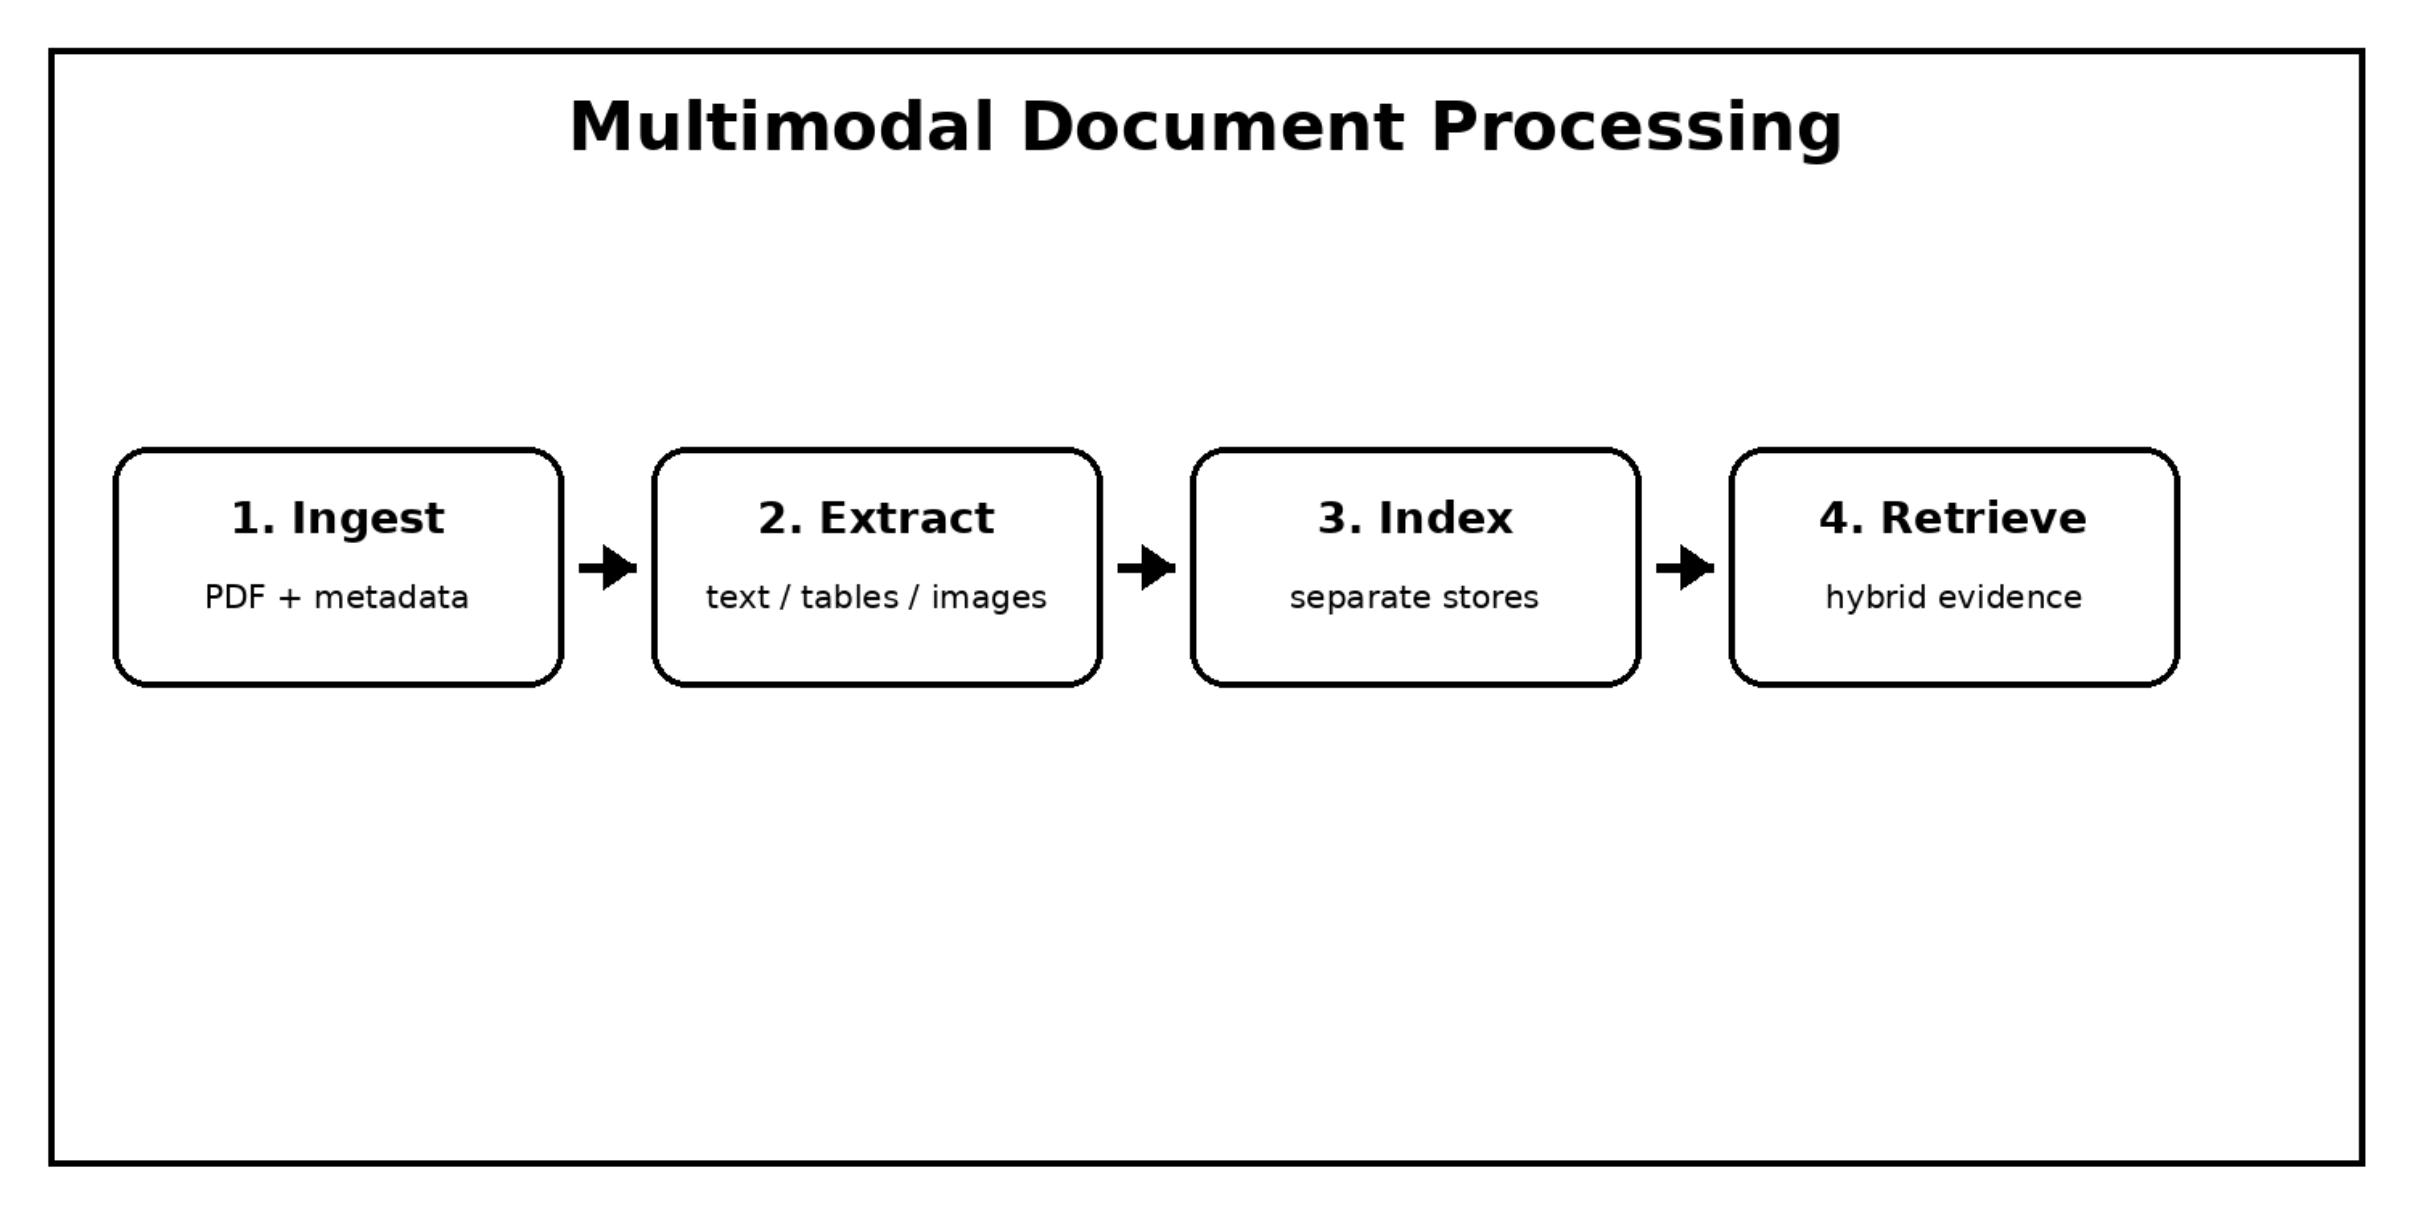

In [20]:
ask("What is Aurora Claims Intelligence Platform?")